File read successfully!
{'time': datetime.datetime(2025, 3, 25, 14, 35), 'lat': array([[-19.208332, -19.208332, -19.208332, ..., -19.208332, -19.208332,
        -19.208332],
       [-19.208332, -19.208332, -19.208332, ..., -19.275827, -19.275827,
        -19.275827],
       [-19.275827, -19.275827, -19.275827, ..., -19.343323, -19.343323,
        -19.343323],
       ...,
       [-22.448074, -22.448074, -22.448074, ..., -22.515566, -22.515566,
        -22.515566],
       [-22.515566, -22.515566, -22.515566, ..., -22.583063, -22.583063,
        -22.583063],
       [-22.583063, -22.583063, -22.583063, ..., -22.583063, -22.583063,
        -22.583063]], shape=(55, 51), dtype=float32), 'lon': array([[111.13332 , 111.20558 , 111.277824, ..., 114.60114 , 114.67339 ,
        114.74563 ],
       [114.81789 , 114.89013 , 114.96238 , ..., 114.31216 , 114.38441 ,
        114.45666 ],
       [114.5289  , 114.60114 , 114.67339 , ..., 114.02318 , 114.09542 ,
        114.16766 ],
       ...,
       [11

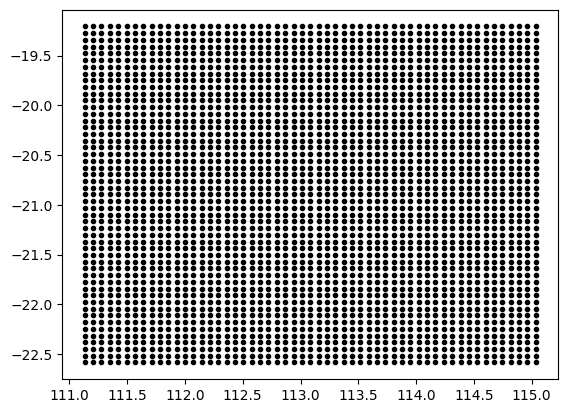

In [ ]:
import os, hfradar
from hfradar.read_wera import read_wera_crad
import importlib 
importlib.reload(hfradar.read_wera)
from hfradar.read_wera import read_wera_crad

cradfile = "20250841435_ptb.crad"
radfile = "20250841430_jtc.rad"

# Try to read the crad file
try:
    result = read_wera_crad(cradfile)
    print("File read successfully!")
    print(result)
except Exception as e:
    print(f"Error: {e}")
    print(f"\nFile exists: {os.path.exists(cradfile)}")
    print(f"File size: {os.path.getsize(cradfile) if os.path.exists(cradfile) else 'N/A'} bytes")


import matplotlib.pyplot as plt 

plt.plot(result['lon'], result['lat'], 'k.')

# Simone's attempt

In [44]:
import numpy as np
import re
import struct
from math import sin, cos, tan, atan, atan2, sqrt, pi


# =============================================================================
# Public API
# =============================================================================

def wera_rad_read(filename, endian="auto", use_cell_centres=True, mask_by_KK=True):
    """
    Read WERA .rad (Fortran unformatted) radial file.

    Parameters
    ----------
    filename : str
    endian : {"auto", "ieee-le", "ieee-be"}
    use_cell_centres : bool
    mask_by_KK : bool

    Returns
    -------
    crad : dict
    """

    if endian == "auto":
        endians = ["ieee-le", "ieee-be"]
    else:
        endians = [endian]

    last_err = None
    for e in endians:
        try:
            crad = _read_with_endian(
                filename,
                endian=e,
                use_cell_centres=use_cell_centres,
                mask_by_KK=mask_by_KK,
            )
            crad["file_endian"] = e
            return crad
        except Exception as err:
            last_err = err

    raise last_err


# =============================================================================
# Core reader
# =============================================================================

def _read_with_endian(filename, endian, use_cell_centres, mask_by_KK):

    endian_char = "<" if endian == "ieee-le" else ">"
    crad = {}

    with open(filename, "rb") as f:

        # ---- first record: header ----
        marker_size, rec1 = _read_first_record_detect_marker(f, endian_char)
        if len(rec1) != 512:
            raise ValueError(f"Header record not 512 bytes (got {len(rec1)})")

        crad["head_bytes"] = np.frombuffer(rec1, dtype=np.uint8)
        crad["head_text"] = _bytes_to_text(crad["head_bytes"])

        lat0, lon0 = _parse_origin_from_header(crad["head_text"])
        dr_m, nrr = _parse_rangeinfo_from_header(crad["head_text"])

        if not np.isfinite(lat0) or not np.isfinite(lon0):
            raise ValueError("Could not parse origin from header")
        if not np.isfinite(dr_m) or dr_m <= 0:
            raise ValueError("Could not parse RANGE from header")
        if not np.isfinite(nrr) or nrr <= 0:
            raise ValueError("Could not parse NRRANGES from header")

        crad["origin"] = {"lat": lat0, "lon": lon0}
        crad["range_res_m"] = dr_m
        crad["nrranges"] = nrr

        # ---- params record: 6 x int16 ----
        buf = _fortran_read_record(f, marker_size, endian_char, "h")
        if len(buf) != 6:
            raise ValueError("Params record not 6 int16")

        NTL, KSIG, KWIN, NRUN, NROB, NRST = map(int, buf)

        nant = -KSIG if KSIG < 0 else KSIG
        if nant <= 0 or nant > 256:
            raise ValueError(f"Unreasonable nant={nant}")

        crad["meta"] = dict(
            NTL=NTL, KSIG=KSIG, KWIN=KWIN,
            NRUN=NRUN, NROB=NROB, NRST=NRST,
            nant=nant
        )

        # ---- ranges ----
        range_index = np.arange(NRUN, NROB + 1, NRST, dtype=int)
        crad["range_index"] = range_index
        crad["n_ranges"] = len(range_index)

        if crad["n_ranges"] != nrr:
            crad["warnings"] = (
                f"NRRANGES(header)={nrr} "
                f"but ranges from records={crad['n_ranges']}"
            )

        if use_cell_centres:
            crad["range_m"] = (range_index - 1) * dr_m + dr_m / 2
        else:
            crad["range_m"] = (range_index - 1) * dr_m

        # ---- per-range loop ----
        ranges = []

        for iran in range_index:

            ss = _fortran_read_record(f, marker_size, endian_char, "f")
            if len(ss) != 2 * nant:
                raise ValueError("SC/SN record mismatch")

            SC = ss[0::2]
            SN = ss[1::2]

            na = _fortran_read_record(f, marker_size, endian_char, "i")
            NUM_ANG = int(na[0])

            if NUM_ANG > 0:
                vr = _fortran_read_record(f, marker_size, endian_char, "f")
                if len(vr) != 6 * NUM_ANG:
                    raise ValueError("V_RADIAL mismatch")
                V = np.reshape(vr, (NUM_ANG, 6)).T
            else:
                V = np.empty((6, 0), dtype=np.float32)

            g = _make_full360_grid(V)

            ranges.append(dict(
                iran=iran,
                SC=SC,
                SN=SN,
                num_ang=NUM_ANG,
                grid360=g
            ))

        crad["ranges"] = ranges

    # ---- stack 360 x Nr ----
    KK, URM, URS, USM, PWR = _stack_full360(crad)

    crad["full360"] = dict(
        angle_deg=np.arange(1, 361),
        KK=KK,
        URM=URM,
        URS=URS,
        USM=USM,
        PWR=PWR
    )

    # ---- stats ----
    U = URM.copy()
    V = URS.copy()
    SN = USM.copy()

    Ur = np.full_like(U, np.nan, dtype=np.float32)
    Ustd = np.full_like(U, np.nan, dtype=np.float32)

    valid = (SN > 0) & np.isfinite(U) & np.isfinite(V)
    Ur[valid] = U[valid] / SN[valid]
    Ustd[valid] = np.abs(np.sqrt(V[valid] / SN[valid] - Ur[valid] ** 2))

    # ---- EN components ----
    theta = np.deg2rad(np.arange(1, 361))[:, None]
    theta = np.broadcast_to(theta, Ur.shape)

    Ue = np.full_like(Ur, np.nan)
    Vn = np.full_like(Ur, np.nan)

    ok = np.isfinite(Ur)

    # print(Ur)
    # print(ok)
    Ue[ok] = Ur[ok] * np.sin(theta[ok])
    Vn[ok] = Ur[ok] * np.cos(theta[ok])

    # ---- lon/lat grid ----
    lat = np.full_like(Ur, np.nan, dtype=np.float64)
    lon = np.full_like(Ur, np.nan, dtype=np.float64)

    for k, r in enumerate(crad["range_m"]):
        lat[:, k], lon[:, k] = _vincenty_direct(
            lat0, lon0, np.arange(1, 361), r
        )

    if mask_by_KK:
        m = ~(KK > 0)
        for arr in (U, V, SN, Ur, Ustd, Ue, Vn, lat, lon):
            arr[m] = np.nan

    crad["data"] = dict(
        U=U, V=V, SN=SN,
        Ur=Ur, Ustd=Ustd,
        Ue=Ue, Vn=Vn,
        lat=lat, lon=lon
    )

    return crad


# =============================================================================
# Helpers
# =============================================================================

def _bytes_to_text(b):
    txt = bytes(b).decode("latin1")
    txt = re.sub(r"[\x00-\x1F]", " ", txt)
    txt = re.sub(r"\s+", " ", txt)
    return txt.strip()


def _parse_origin_from_header(hdr):
    lon = lat = np.nan

    mlon = re.search(r"LAENGE:\s*(\d+)-(\d+)-(\d+)\s*([EW])", hdr)
    mlat = re.search(r"EBREITE:\s*(\d+)-(\d+)-(\d+)\s*([NS])", hdr)

    if mlon:
        d, m, s, h = mlon.groups()
        lon = _dms2deg(d, m, s)
        if h == "W":
            lon = -lon

    if mlat:
        d, m, s, h = mlat.groups()
        lat = _dms2deg(d, m, s)
        if h == "S":
            lat = -lat

    return lat, lon


def _parse_rangeinfo_from_header(hdr):
    dr = nrr = np.nan

    m = re.search(r"RANGE:\s*([0-9.]+)\s*KM", hdr)
    if m:
        dr = 1000 * float(m.group(1))

    m = re.search(r"NRRANGES:\s*(\d+)", hdr)
    if m:
        nrr = int(m.group(1))

    return dr, nrr


def _dms2deg(d, m, s):
    return float(d) + float(m) / 60 + float(s) / 3600


# =============================================================================
# 360-grid
# =============================================================================

def _make_full360_grid(V):
    g = dict(
        KK=np.full(360, np.nan, np.float32),
        URM=np.full(360, np.nan, np.float32),
        URS=np.full(360, np.nan, np.float32),
        USM=np.full(360, np.nan, np.float32),
        PWR=np.full(360, np.nan, np.float32),
    )

    if V.size == 0:
        return g

    a = np.clip(np.round(V[0]).astype(int), 1, 360) - 1

    g["KK"][a] = V[1]
    g["URM"][a] = V[2]
    g["URS"][a] = V[3]
    g["USM"][a] = V[4]
    g["PWR"][a] = V[5]

    return g


def _stack_full360(crad):
    nr = crad["n_ranges"]

    KK = np.full((360, nr), np.nan, np.float32)
    URM = KK.copy()
    URS = KK.copy()
    USM = KK.copy()
    PWR = KK.copy()

    for k, r in enumerate(crad["ranges"]):
        g = r["grid360"]
        KK[:, k] = g["KK"]
        URM[:, k] = g["URM"]
        URS[:, k] = g["URS"]
        USM[:, k] = g["USM"]
        PWR[:, k] = g["PWR"]

    return KK, URM, URS, USM, PWR


# =============================================================================
# Vincenty direct (WGS84)
# =============================================================================

def _vincenty_direct(lat1_deg, lon1_deg, alpha1_deg, s_m):
    a = 6378137.0
    f = 1 / 298.257223563
    b = a * (1 - f)

    alpha1 = np.deg2rad(alpha1_deg)
    s = np.full_like(alpha1, float(s_m))

    lat1 = np.deg2rad(lat1_deg)
    lon1 = np.deg2rad(lon1_deg)

    U1 = np.arctan((1 - f) * np.tan(lat1))
    sinU1 = np.sin(U1)
    cosU1 = np.cos(U1)

    sinAlpha1 = np.sin(alpha1)
    cosAlpha1 = np.cos(alpha1)

    sinAlpha = cosU1 * sinAlpha1
    cosSqAlpha = 1 - sinAlpha ** 2

    uSq = cosSqAlpha * (a ** 2 - b ** 2) / b ** 2

    A = 1 + uSq / 16384 * (4096 + uSq * (-768 + uSq * (320 - 175 * uSq)))
    B = uSq / 1024 * (256 + uSq * (-128 + uSq * (74 - 47 * uSq)))

    sigma = s / (b * A)
    sigmaP = np.inf

    sigma1 = np.arctan2(np.tan(U1), cosAlpha1)

    for _ in range(100):
        sinSigma = np.sin(sigma)
        cosSigma = np.cos(sigma)
        cos2SigmaM = np.cos(2 * sigma1 + sigma)

        deltaSigma = B * sinSigma * (
            cos2SigmaM
            + B / 4 * (
                cosSigma * (-1 + 2 * cos2SigmaM ** 2)
                - B / 6 * cos2SigmaM * (-3 + 4 * sinSigma ** 2)
                * (-3 + 4 * cos2SigmaM ** 2)
            )
        )

        sigmaNew = s / (b * A) + deltaSigma
        if np.max(np.abs(sigmaNew - sigmaP)) < 1e-12:
            sigma = sigmaNew
            break
        sigmaP = sigma
        sigma = sigmaNew

    sinSigma = np.sin(sigma)
    cosSigma = np.cos(sigma)

    lat2 = np.arctan2(
        sinU1 * cosSigma + cosU1 * sinSigma * cosAlpha1,
        (1 - f) * np.sqrt(sinAlpha ** 2 + (sinU1 * sinSigma - cosU1 * cosSigma * cosAlpha1) ** 2)
    )

    lam = np.arctan2(
        sinSigma * sinAlpha1,
        cosU1 * cosSigma - sinU1 * sinSigma * cosAlpha1
    )

    C = f / 16 * cosSqAlpha * (4 + f * (4 - 3 * cosSqAlpha))
    L = lam - (1 - C) * f * sinAlpha * (
        sigma + C * sinSigma * (
            cos2SigmaM + C * cosSigma * (-1 + 2 * cos2SigmaM ** 2)
        )
    )

    lon2 = (lon1 + L + pi) % (2 * pi) - pi

    return np.rad2deg(lat2), np.rad2deg(lon2)


# =============================================================================
# Fortran unformatted I/O
# =============================================================================

def _read_first_record_detect_marker(f, endian):
    pos = f.tell()

    # try 4-byte
    f.seek(pos)
    try:
        L = struct.unpack(endian + "i", f.read(4))[0]
        if 0 < L < 1e7:
            rec = f.read(L)
            L2 = struct.unpack(endian + "i", f.read(4))[0]
            if L == L2:
                return 4, rec
    except Exception:
        pass

    # try 8-byte
    f.seek(pos)
    L = struct.unpack(endian + "q", f.read(8))[0]
    if 0 < L < 1e7:
        rec = f.read(L)
        L2 = struct.unpack(endian + "q", f.read(8))[0]
        if L == L2:
            return 8, rec

    raise ValueError("Could not detect Fortran record marker size")


def _fortran_read_record(f, marker_size, endian, fmt):
    if marker_size == 4:
        L = struct.unpack(endian + "i", f.read(4))[0]
    else:
        L = struct.unpack(endian + "q", f.read(8))[0]

    if L < 0:
        raise ValueError("Negative record length")

    data = f.read(L)

    if marker_size == 4:
        L2 = struct.unpack(endian + "i", f.read(4))[0]
    else:
        L2 = struct.unpack(endian + "q", f.read(8))[0]

    if L != L2:
        raise ValueError("Record length trailer mismatch")

    dtype = {
        "h": np.int16,
        "i": np.int32,
        "f": np.float32,
    }[fmt]

    return np.frombuffer(data, dtype=dtype)

In [45]:
result = wera_rad_read(radfile, endian="ieee-le")

/tmp/ipykernel_15810/4132712080.py:172: RuntimeWarning: invalid value encountered in sqrt
  Ustd[valid] = np.abs(np.sqrt(V[valid] / SN[valid] - Ur[valid] ** 2))


result['data']

In [61]:
result['data']

{'U': array([[          nan,           nan,           nan, ...,           nan,
                   nan,           nan],
        [          nan,           nan,           nan, ...,           nan,
                   nan,           nan],
        [          nan,           nan,           nan, ...,           nan,
                   nan,           nan],
        ...,
        [          nan, 7.4037825e-07,           nan, ...,           nan,
                   nan,           nan],
        [          nan, 1.1349422e-06,           nan, ...,           nan,
                   nan,           nan],
        [          nan, 6.9909352e-06,           nan, ...,           nan,
                   nan,           nan]], shape=(360, 100), dtype=float32),
 'V': array([[          nan,           nan,           nan, ...,           nan,
                   nan,           nan],
        [          nan,           nan,           nan, ...,           nan,
                   nan,           nan],
        [          nan,       

In [ ]:
ind = np.logical_or(result['data']['V']>1, result['data']['U']>1 )

U = result['data']['U']
V = result['data']['V']

U[ind] = np.nan
V[ind] = np.nan

Selected resolution: f


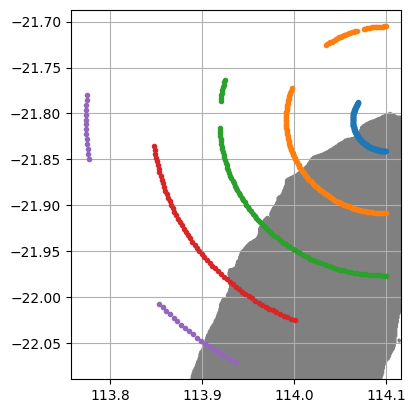

In [73]:
import afloat.plot.plotting as zplot

plt.plot(result['data']['lon'], result['data']['lat'], '.')
plt.quiver(result['data']['lon'], result['data']['lat'], U, V)
plt.gca().set_aspect('equal')
verts = zplot.global_coast_fill(resolution='f')

plt.grid()

In [ ]:
import xarray as xr
import numpy as np

angle = np.arange(1, 361)
range_m = result["range_m"]

ds = xr.Dataset(
    data_vars=dict(
        KK   =(("angle", "range"), result["full360"]["KK"]),
        URM  =(("angle", "range"), result["full360"]["URM"]),
        URS  =(("angle", "range"), result["full360"]["URS"]),
        USM  =(("angle", "range"), result["full360"]["USM"]),
        PWR  =(("angle", "range"), result["full360"]["PWR"]),

        Ur   =(("angle", "range"), result["data"]["Ur"]),
        Ustd =(("angle", "range"), result["data"]["Ustd"]),
        Ue   =(("angle", "range"), result["data"]["Ue"]),
        Vn   =(("angle", "range"), result["data"]["Vn"]),

        lat  =(("angle", "range"), result["data"]["lat"]),
        lon  =(("angle", "range"), result["data"]["lon"]),
    ),
    coords=dict(
        angle=("angle", angle,
               {"long_name": "bearing",
                "units": "degrees",
                "comment": "clockwise from true north"}),

        range=("range", range_m,
               {"long_name": "range from radar",
                "units": "m"})
    ),
    attrs=dict(
        title="WERA HF radar radial velocities",
        institution="Generated from WERA .rad",
        source="wera_rad_read (Python)",
        history="Converted from Fortran unformatted .rad",
        radar_latitude=result["origin"]["lat"],
        radar_longitude=result["origin"]["lon"],
        range_resolution_m=result["range_res_m"],
        n_ranges=result["n_ranges"],
        endian=result.get("file_endian", "unknown"),
    )
)

ds.to_netcdf(radfile + '.nc')

Selected resolution: f


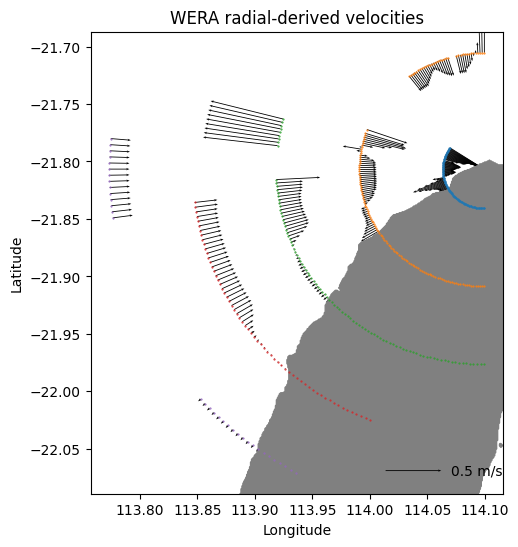

In [87]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))

# scatter of all lon/lat points
ax.plot(ds.lon.values, ds.lat.values, '.', markersize=1)

# subsampling
step_angle = 1
step_range = 1

lon = ds.lon.values[::step_angle, ::step_range]
lat = ds.lat.values[::step_angle, ::step_range]
Ue  = ds.Ue.values[::step_angle, ::step_range]
Vn  = ds.Vn.values[::step_angle, ::step_range]

# local metres → degrees conversion
lat0 = np.nanmean(lat)
m_per_deg_lat = 111_320.0
m_per_deg_lon = 111_320.0 * np.cos(np.deg2rad(lat0))

Udeg = Ue / m_per_deg_lon
Vdeg = Vn / m_per_deg_lat

q = ax.quiver(
    lon, lat,
    Udeg, Vdeg,
    angles='xy',
    scale_units='xy',
    scale=0.0001,
    width=0.002,
    headwidth=3,
    headlength=4,
    headaxislength=3,
)

ax.set_aspect('equal', adjustable='box')
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("WERA radial-derived velocities")

# coastline
verts = zplot.global_coast_fill(resolution='f')

# reference vector
ax.quiverkey(
    q, 0.85, 0.05,
    0.5 / m_per_deg_lon,   # 0.5 m/s
    "0.5 m/s",
    labelpos='E'
)

plt.show()

In [34]:
# Below my attempts

In [ ]:
# Inspect .crad/.rad header and extract key fields per WERA RAD spec
import re

# cradfile = "20250841435_ptb.crad"

print('Reading header from', radfile)
try:
    with open(radfile, 'rb') as f:
        # Many WERA files use Fortran record markers: skip leading 4 bytes
        try:
            f.seek(4)
        except Exception:
            pass
        head = f.read(512)
        # skip trailing 4 bytes if present
        # f.seek(4, 1)

    header_text = head.decode('ascii', errors='replace')
    print('--- Header (first 512 bytes) ---')
    print(header_text)
    print('--- End header ---\n')

    # Try to extract common header fields
    def find_int(key):
        m = re.search(rf"{key}[^0-9\-\+\.]*(\d+)", header_text, re.IGNORECASE)
        return int(m.group(1)) if m else None

    def find_word(key):
        m = re.search(rf"{key}[\s:=]*([A-Z0-9_\-]+)", header_text, re.IGNORECASE)
        return m.group(1) if m else None

    hdcode = find_word('HDCODE') or find_word('HDC') or ( 'FMRADG' if 'FMRADG' in header_text.upper() else None)
    nx = find_int('NX')
    ny = find_int('NY')

    print('HDCODE:', hdcode)
    print('NX:', nx)
    print('NY:', ny)

except FileNotFoundError:
    print('File not found:', radfile)
except Exception as e:
    print('Error reading header:', e)

# Next step: implement reading of arrays (LAT, LON, KUR, URM, URS, USM, PWR)
print('\nNext: run the RAD reader prototype cell to attempt data extraction (will be added).')


Reading header from 20250841430_jtc.rad
--- Header (first 512 bytes) ---
1024 SAMPLES   25-MAR-25 14:30 UTC  jtc         FMRADD FREQUENZ   5.262MHZ YEAR 2025     RANGE:  7.5000 KM,TRUENORTH:318 GRAD,RATE:0.260000S,NRRANGES:100 0000000 LAENGE:114-05-59 EBREITE: 21-48-25 S MT:  1536 PWR: 4095 ANT:12 MD:031 OFFSET:0.10RXOFFSET:         0SS 0.000000 HD:000       20240611T0830 restart daq after inspection, drive swap and install PDU                          0000000 0000000 0000000 0000000 0000000 0000000 0000000 0000000 0000000 0000000 0000000 0000000 0000000 0000000 0000000 0000000 
--- End header ---

HDCODE: None
NX: None
NY: None

Next: run the RAD reader prototype cell to attempt data extraction (will be added).


In [27]:
# RAD reader prototype: read LAT, LON, KUR, URM, URS, USM, PWR blocks and compute radial velocities
import struct
import numpy as np

radfile = radfile  # use existing variable from notebook

def read_block(fid, dtype, count):
    """Read a block that may be wrapped with 4-byte Fortran record markers.

    Returns a 1D numpy array of length `count` with dtype `dtype`.
    """
    pos = fid.tell()
    head = fid.read(4)
    if len(head) < 4:
        raise EOFError('Unexpected EOF while reading record marker')
    blen = struct.unpack('<i', head)[0]
    expected = np.dtype(dtype).itemsize * count
    if blen == expected:
        raw = fid.read(blen)
        # consume trailing marker
        trailing = fid.read(4)
        return np.frombuffer(raw, dtype=dtype)
    else:
        # Not matching expected length — roll back and signal caller
        fid.seek(pos)
        return None

result = None
try:
    with open(radfile, 'rb') as fid:
        # Skip initial 4-byte record marker if present
        try:
            fid.seek(4)
        except Exception:
            pass

        head = fid.read(512)
        # Skip trailing 4-byte marker
        try:
            fid.seek(4, 1)
        except Exception:
            pass

        # Now read data-section header (int16 x6): NTL, KSIG, KWIN, NX, NY, I2NN
        pos = fid.tell()
        marker = fid.read(4)
        if len(marker) == 4:
            mval = struct.unpack('<i', marker)[0]
            if mval == 12:
                data = fid.read(12)
                try:
                    fid.read(4)
                except Exception:
                    pass
            else:
                fid.seek(pos)
                data = fid.read(12)
        else:
            raise EOFError('Unexpected EOF reading data header')

        NTL, KSIG, KWIN, NX, NY, I2NN = struct.unpack('<6h', data)
        NC = NX * NY
        print(f'NX NyY NC = {NX} {NY} {NC}')

        # Attempt to read contiguous blocks first
        lat = read_block(fid, np.float32, NC)
        if lat is not None:
            lon = read_block(fid, np.float32, NC)
            kur = read_block(fid, np.int32, NC)
            urm = read_block(fid, np.float32, NC)
            urs = read_block(fid, np.float32, NC)
            usm = read_block(fid, np.float32, NC)
            pwr = read_block(fid, np.float32, NC)
        else:
            print('NAH')
            # # Likely per-record layout (e.g., marker == record_size like 32)
            # # Read next 4 bytes to determine per-record size
            # pos2 = fid.tell()
            # mk = fid.read(4)
            # if len(mk) < 4:
            #     raise EOFError('Unexpected EOF determining record size')
            # rec_len = struct.unpack('<i', mk)[0]
            # print('Per-record length detected:', rec_len)
            # # Go back to start of first record
            # fid.seek(pos2)

            # # Preallocate arrays
            # lats = np.empty(NC, dtype=np.float32)
            # lons = np.empty(NC, dtype=np.float32)
            # kurs = np.empty(NC, dtype=np.int32)
            # urms = np.empty(NC, dtype=np.float32)
            # urss = np.empty(NC, dtype=np.float32)
            # usms = np.empty(NC, dtype=np.float32)
            # pwrs = np.empty(NC, dtype=np.float32)
            # extras = np.empty(NC, dtype=np.int32)

            # for i in range(NC):
            #     # read marker
            #     mark = fid.read(4)
            #     if len(mark) < 4:
            #         raise EOFError('Unexpected EOF reading record marker in loop')
            #     bl = struct.unpack('<i', mark)[0]
            #     rec = fid.read(bl)
            #     # consume trailing marker
            #     try:
            #         fid.read(4)
            #     except Exception:
            #         pass
            #     # Try unpacking as: lat(float32), lon(float32), kur(int32), urm(float32), urs(float32), usm(float32), pwr(float32), extra(int32)
            #     if len(rec) >= 32:
            #         try:
            #             f0, f1, i2, f3, f4, f5, f6, i7 = struct.unpack('<ffiffffi', rec[:32])
            #             lats[i] = f0 * 180.0 / np.pi
            #             lons[i] = f1 * 180.0 / np.pi
            #             kurs[i] = i2
            #             urms[i] = f3
            #             urss[i] = f4
            #             usms[i] = f5
            #             pwrs[i] = f6
            #             extras[i] = i7
            #         except struct.error:
            #             # fallback: try different ordering or types
            #             # fill with NaNs to indicate parse failure
            #             lats[i] = np.nan
            #             lons[i] = np.nan
            #             kurs[i] = 0
            #             urms[i] = np.nan
            #             urss[i] = np.nan
            #             usms[i] = np.nan
            #             pwrs[i] = np.nan
            #             extras[i] = 0
            #     else:
            #         # insufficient length
            #         lats[i] = np.nan
            #         lons[i] = np.nan
            #         kurs[i] = 0
            #         urms[i] = np.nan
            #         urss[i] = np.nan
            #         usms[i] = np.nan
            #         pwrs[i] = np.nan
            #         extras[i] = 0

            # # Assign variables
            # lat = lats
            # lon = lons
            # kur = kurs
            # urm = urms
            # urs = urss
            # usm = usms
            # pwr = pwrs
            raise(Exception)

    # Compute radial velocity and statistics
    ur = np.full(NC, np.nan, dtype=np.float32)
    sig = np.full(NC, np.nan, dtype=np.float32)
    ik = kur > 0
    with np.errstate(invalid='ignore', divide='ignore'):
        ur[ik] = urm[ik] / usm[ik]
        sig[ik] = np.sqrt(np.maximum(0.0, urs[ik] / usm[ik] - ur[ik] ** 2))
    sigm = sig / np.sqrt(np.maximum(kur, 1))

    # Reshape to grid (NX, NY)
    u_grid = ur.reshape((NX, NY))
    lat_grid = lat.reshape((NX, NY))
    lon_grid = lon.reshape((NX, NY))
    pwr_grid = pwr.reshape((NX, NY))
    uvar_grid = sig.reshape((NX, NY))
    uacc_grid = sigm.reshape((NX, NY))

    result = {
        'time': None,
        'lat': lat_grid,
        'lon': lon_grid,
        'u': u_grid,
        'uvar': uvar_grid,
        'uacc': uacc_grid,
        'pwr': pwr_grid,
        'raw_kur': kur.reshape((NX, NY)),
        'header_text': head.decode('ascii', errors='replace')
    }

    print('Read successful: shapes:')
    print('lat, lon, u shapes:', lat_grid.shape, lon_grid.shape, u_grid.shape)
    print('Sample values (center):', u_grid[NX//2, NY//2], lat_grid[NX//2, NY//2], lon_grid[NX//2, NY//2])

except FileNotFoundError:
    print('File not found:', radfile)
except Exception as e:
    print('Error during RAD read prototype:', e)

# Make `result` available to other notebook cells
result


NX NyY NC = 1 100 100
NAH
Error during RAD read prototype: 


In [20]:
# Diagnostic: inspect raw bytes at the LAT block start and interpret several ways
import struct

print('Diagnostic for', radfile)
try:
    with open(radfile, 'rb') as fid:
        # replicate previous positioning logic to reach LAT block
        try:
            fid.seek(4)
        except Exception:
            pass
        header = fid.read(512)
        try:
            fid.seek(4, 1)
        except Exception:
            pass
        # read possible marker before data-section header
        pos = fid.tell()
        marker = fid.read(4)
        if len(marker) == 4 and struct.unpack('<i', marker)[0] == 12:
            # wrapped header
            data_hdr = fid.read(12)
            fid.read(4)
        else:
            fid.seek(pos)
            data_hdr = fid.read(12)
        NTL, KSIG, KWIN, NX, NY, I2NN = struct.unpack('<6h', data_hdr)
        NC = NX * NY
        print('NX, NY, NC:', NX, NY, NC)

        # Now find start offset for LAT block using same logic as read_block
        # Check next 4 bytes as marker
        lat_pos = fid.tell()
        marker = fid.read(4)
        if len(marker) == 4:
            blen = struct.unpack('<i', marker)[0]
            print('Next marker int32 (little):', blen)
            expected = 4 * NC
            print('Expected bytes for float32 NC:', expected)
            if blen == expected:
                start = fid.tell()
            else:
                # maybe no markers
                start = lat_pos
                fid.seek(lat_pos)
        else:
            start = lat_pos
            fid.seek(lat_pos)

        # Read first 64 bytes of LAT block
        raw = fid.read(64)
        print('Raw bytes (first 64):', raw.hex())

        # Interpret as 16 float32 little-endian
        floats_le = struct.unpack('<16f', raw)
        floats_be = struct.unpack('>16f', raw)
        print('\nFirst 8 float32 little-endian:', floats_le[:8])
        print('First 8 float32 big-endian   :', floats_be[:8])

        # Also interpret first 8 int32 little/big for exploration
        ints_le = struct.unpack('<8i', raw)
        ints_be = struct.unpack('>8i', raw)
        print('\nFirst 8 int32 little-endian:', ints_le[:8])
        print('First 8 int32 big-endian   :', ints_be[:8])

        # Show header snippet
        print('\nHeader snippet:')
        print(header.decode('ascii', errors='replace')[:400])

except FileNotFoundError:
    print('File not found:', radfile)
except Exception as e:
    print('Diagnostic error:', e)


Diagnostic for 20250841430_jtc.rad
NX, NY, NC: 1 100 100
Next marker int32 (little): 32
Expected bytes for float32 NC: 400
Raw bytes (first 64): 200000003a20bd50509f294d216a1651d6192f4d968320518c4c0e4dce678e5045cc404d20000000040000007d00000004000000b80b0000000034430000f442

First 8 float32 little-endian: (4.484155085839415e-44, 25384046592.0, 177861888.0, 40376602624.0, 183606624.0, 43087650816.0, 149211328.0, 19113340928.0)
First 8 float32 big-endian   : (1.0842021724855044e-19, 0.0006131725385785103, 21362272256.0, 7.931181938074948e-19, -42107108589568.0, -2.1184585973583773e-25, -1.5719891831018205e-31, -971215872.0)
Diagnostic error: unpack requires a buffer of 32 bytes


In [21]:
result

{'time': None,
 'lat': array([[2.56858009e-42, 1.45439877e+12, 1.01907354e+10, 2.31340874e+12,
         1.05198848e+10, 2.46874060e+12, 8.54917939e+09, 1.09511377e+12,
         1.15831030e+10, 2.56858009e-42, 3.20897348e-43, 1.00360996e-41,
         3.20897348e-43, 2.40864989e-40, 1.03132402e+04, 6.99008496e+03,
         1.50935245e+00, 2.77038908e+00, 1.31389809e+00, 5.28121007e+13,
         1.03705361e+04, 7.27656396e+03, 2.22260380e+00, 3.82614040e+00,
         1.81964755e+00, 6.03369043e+13, 1.04278320e+04, 7.39115527e+03,
         2.98498464e+00, 4.91098785e+00, 2.34805846e+00, 6.83473791e+13,
         1.04851270e+04, 8.02140869e+03, 3.65463138e+00, 5.83398962e+00,
         2.80212474e+00, 7.63769169e+13, 1.05424229e+04, 8.93814160e+03,
         4.15447855e+00, 6.51142883e+00, 3.13096404e+00, 8.77316863e+13,
         1.05997188e+04, 1.00840566e+04, 4.40035772e+00, 6.84770393e+00,
         3.28546143e+00, 1.02980817e+14, 1.06570146e+04, 1.12872686e+04,
         4.62004471e+00, 7.23

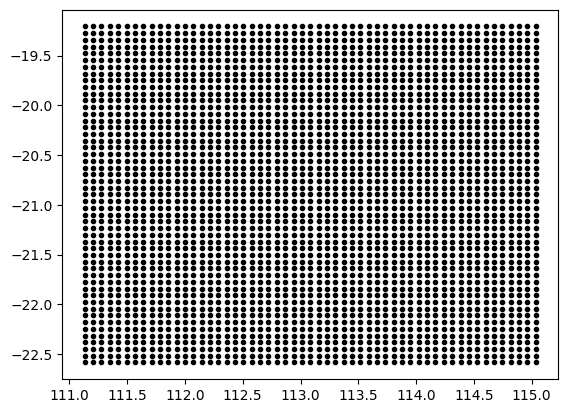